In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Understanding

In [6]:
# load dataset into python
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')


In [7]:
# Display the first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
# identify
# no of rows and colums
print(f"No of rows: {df.shape[0]}")
print(f"No of Columns: {df.shape[1]}")

# Data type of all columns
print(f"Data type of all columns: \n{df.dtypes}")

# Numerical features
num_column = df.select_dtypes(include='number').columns
print(num_column)

# Categorical Features
cat_column = df.select_dtypes(include='object').columns
print(cat_column)

# unique features
unique_features = [cols for cols in df.columns if df[cols].is_unique]
print(f'Unique identifiers {unique_features}')
    

No of rows: 541909
No of Columns: 8
Data type of all columns: 
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')
Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')
Unique identifiers []


### The Online Retail dataset contains transactional data from an online retail store. Each row represents a single item purchased within an invoice.

It includes:

Invoice Number
Product details:
- na.Stock code 
- b. product description.
- Transaction quantities: Number of items bought per product line.
- Invoice date
- Pricing: Unit price of each item.
- Customer ID (when available).
- Geographic data: Country of the customer.


## Data Cleaning

In [9]:
# columns with missing values
df.columns[df.isna().any()].to_list()

['Description', 'CustomerID']

In [10]:
# number of missing values per column
df.isna().sum()[df.isna().sum()>0]

Description      1454
CustomerID     135080
dtype: int64

In [11]:
# Calculate the number of missing value per columns to determine if i am supposed to delete the column or not

missing_values = df.isna().sum()/len(df)*100
print(missing_values)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [12]:
# Handle missing value appropriately by removing customer ID with missing value
df = df.dropna(subset=['CustomerID'])


In [13]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Handling Missing Values

- CustomerID contained a substantial number of missing values.
- Since CustomerID is essential for customer behavior analysis and could not be accurately imputed, rows with missing CustomerID were removed.

- After removing rows with missing CustomerID, no missing values remained in the Description column. This indicates that the records with missing descriptions overlapped with those missing CustomerID.

- Therefore, no additional action was required for the Description column.
This approach ensured that only complete and reliable transaction records were retained for analysis.

In [14]:
# Duplicates records
# identify duplicates rows
duplicate_records = df.duplicated().sum()
print(duplicate_records)

5225


In [15]:
# remove duplicates
before_duplicate = len(df)

df = df.drop_duplicates()

after_duplicate = len(df)

# Show the number of duplicates removed
print(f"No of duplicates removed: {before_duplicate - after_duplicate}")

No of duplicates removed: 5225


In [16]:
# Standardization
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [17]:
# Date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [18]:
# Consistency in text formating for description
df['Description'] = df['Description'].str.strip().str.upper()

In [19]:
#Consistency in text formating for Country
df['Country'] = df['Country'].str.strip().str.title()

In [20]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [21]:
# Consistency in column name
df_columns  = df.columns.str.strip().str.replace(' ', '_')

In [22]:
# Data types
df.dtypes
df['CustomerID']= df['CustomerID'].astype(int)
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

## Data Validation

In [23]:
# Invalid invoice number that starts with c, 
df['InvoiceNo'] = df['InvoiceNo'].str.replace('C', '').str.strip()
# print(invalid_invoice)


In [24]:
# invalide stock code that has letters
df['StockCode'] = df['StockCode'].str.extract(r'(\d+)')

In [25]:
negative_quatity = (df['Quantity'] < 0).sum()
print(f"No of Quantity less than zero: {negative_quatity}")

No of Quantity less than zero: 8872


In [26]:
# remove negative quatity
df = df[df['Quantity']>0]

In [27]:
df.columns
print(f"No of Unit price less than zero: {(df['UnitPrice'] <0).sum()}")

No of Unit price less than zero: 0


In [28]:
# Detect and handle Ourliers with IQR method
q1  = df['Quantity'].quantile(0.25)
q3 = df['Quantity'].quantile(0.75)

iqr = q3-q1

lower = q1 -1.5 *iqr
upper = q3+1.5 * iqr

print(f"Lower Bound: {lower}")
print(f"Upper bound: {upper}")

outliers = df[(df['Quantity'] < lower)|( df['Quantity']> upper)]
print(len(outliers))

Lower Bound: -13.0
Upper bound: 27.0
25625


We will identify and document quantity outliers but retain them because they may represent legitimate high-volume purchases.

## Cleaning Summary



In [29]:
cleaning_summary = pd.DataFrame({
    'Issues Found':['Missing Values', 'Duplicates', 'Invalid Entries', 'Standardization'], 
    'Action Taken':['Customer rows with missing values are dropped which automatically dropped description rows with missing value because they are ourlapping', 'Duplicates records were removed', 'a. The letter \'c\' was removed from Invoice number starting with C. \nb. Letters were removed from Stock Code that has letter. \nc. Negative number of quantities were removed.', 'Invoice date column was appropriately formatted in date time format \n Description Column was formatted to upper case \nCountry column was formattted to title case \nColumn names are consistent \n all Columns are in their appropriate data types']
})
print(cleaning_summary)

      Issues Found                                       Action Taken
0   Missing Values  Customer rows with missing values are dropped ...
1       Duplicates                    Duplicates records were removed
2  Invalid Entries  a. The letter 'c' was removed from Invoice num...
3  Standardization  Invoice date column was appropriately formatte...


## EDA

In [30]:
df['Revenue'] = df['Quantity'] *df['UnitPrice']
df.columns

C:\Users\Kawthar\AppData\Local\Temp\ipykernel_24152\982654714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Quantity'] *df['UnitPrice']


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

In [31]:
# summary statistics
df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,22.629195
std,181.588420,22.240725,311.083465
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.390000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [32]:
# Numerical columns
summary_stats = pd.DataFrame({
    "Mean": df[['Quantity', 'UnitPrice', 'Revenue']].mean(),
    'Median':df[['Quantity', 'UnitPrice', 'Revenue']].median(),
    'Minimum Value': df[['Quantity', 'UnitPrice', 'Revenue']].min(),
    'Maximum Value': df[['Quantity', 'UnitPrice', 'Revenue']].max(),
    "Standard Deviation": df[['Quantity', 'UnitPrice', 'Revenue']].std()
})
print(summary_stats)


                Mean  Median  Minimum Value  Maximum Value  Standard Deviation
Quantity   13.153718    6.00            1.0       80995.00          181.588420
UnitPrice   3.125596    1.95            0.0        8142.75           22.240725
Revenue    22.629195   12.39            0.0      168469.60          311.083465


In [33]:
print(f"Top  5 selling products: \n")

top = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
print(top)

Top  5 selling products: 

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64


In [34]:
print("Highest revenue generating country")
high_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
print(high_country)

Highest revenue generating country
Country
United Kingdom    7285024.644
Netherlands        285446.340
Eire               265262.460
Germany            228678.400
France             208934.310
Name: Revenue, dtype: float64


In [35]:
print("Monthly Sales trend")
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('YearMonth')['Revenue'].sum()

Monthly Sales trend


C:\Users\Kawthar\AppData\Local\Temp\ipykernel_24152\2272794413.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')


YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

In [36]:
print("Most Purchased products")
most_purchasing = df['Description'].value_counts().head(10)
print(most_purchasing)

Most Purchased products
Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1714
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1390
LUNCH BAG RED RETROSPOT               1303
SET OF 3 CAKE TINS PANTRY DESIGN      1152
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1078
PACK OF 72 RETROSPOT CAKE CASES       1050
Name: count, dtype: int64


In [47]:
print("Customer Purchasing behaviour: ")
highest_revenue_customer = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(5)
print(highest_revenue_customer)

Customer Purchasing behaviour: 
CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
Name: Revenue, dtype: float64


## Data Visualization

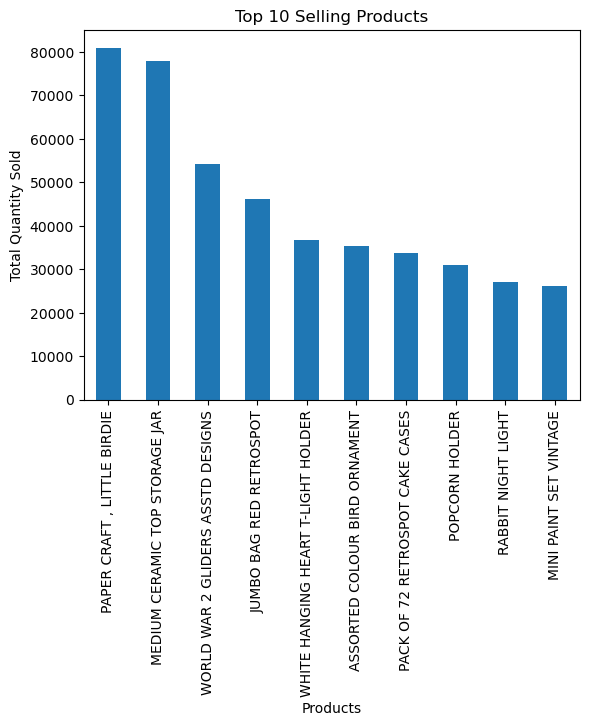

In [ ]:
#  bar chart
top_product = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.Figure(figsize=(12, 6))
top_product.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90)

plt.show()

The Bar chart shows the products with the highest quantities sold. The 'Paper Craft, Little Birdie' is the highest selling product

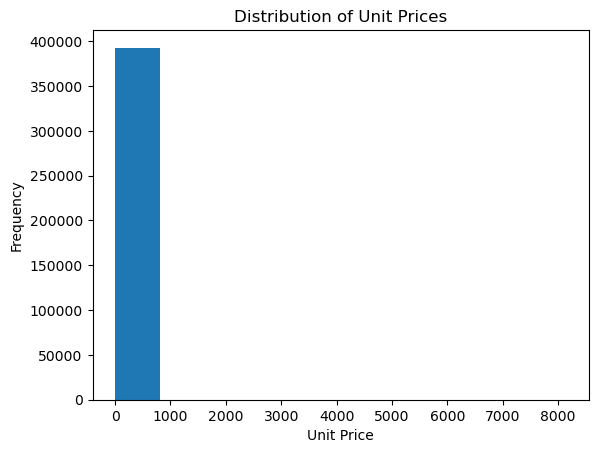

In [38]:
# Histogram

plt.Figure(figsize=(10, 6))
plt.hist(df['UnitPrice'], bins = 10)
plt.title('Distribution of Unit Prices')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

The histogram shows how product prices are distributed across transactions. Most products tend to fall within lower price ranges.

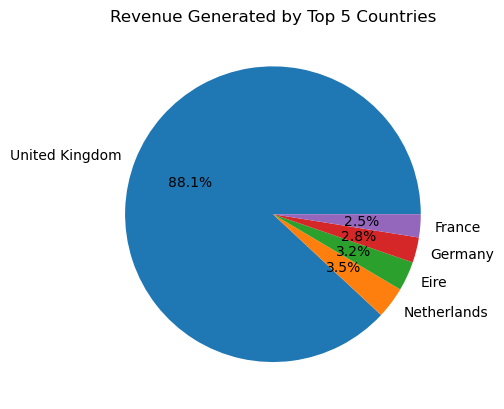

In [39]:
# pie chart
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head()
plt.pie(top_countries,     labels=top_countries.index,
    autopct='%1.1f%%'
)
plt.title('Revenue Generated by Top 5 Countries')
plt.show()

The pie chart illustrates the proportion of revenue generated by the top five countries. United Kindom generated the highest Revenue of 88.1%

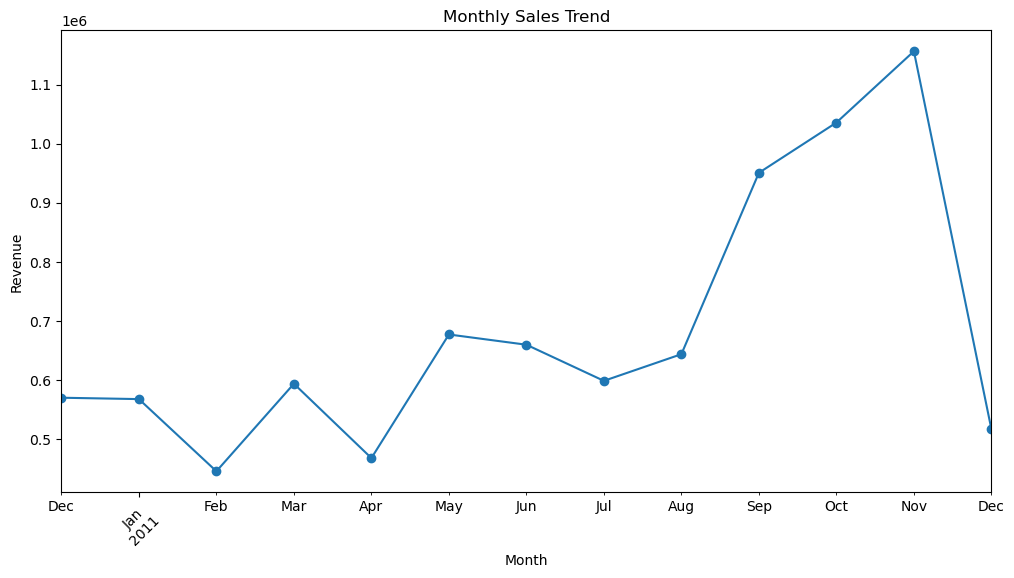

In [ ]:
# line chart
monthly_sales = df.groupby('YearMonth')['Revenue'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

The line chart illustrates fluctuations in monthly revenue, helping identify seasonal trends and peak sales periods. Highest revenue is in November

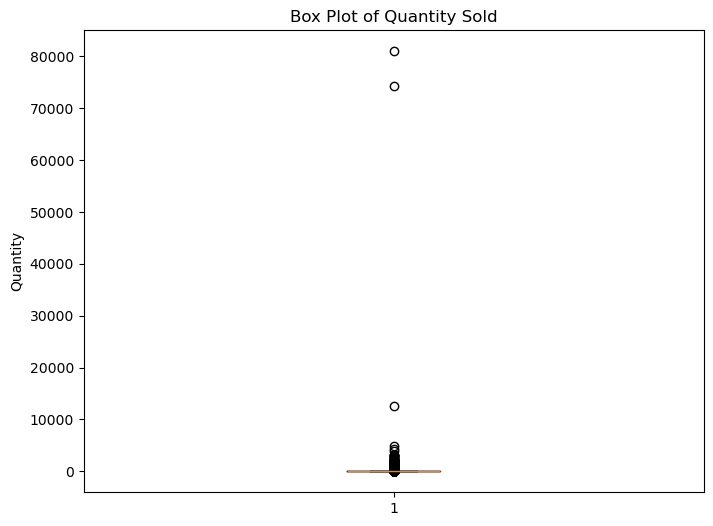

In [41]:
# Box Plot
plt.figure(figsize=(8,6))

plt.boxplot(df['Quantity'])

plt.title('Box Plot of Quantity Sold')
plt.ylabel('Quantity')

plt.show()

The box plot highlights the spread of quantities sold and identifies potential outliers representing bulk purchases.

## Insights

- The majority of revenue was generated from customers in United Kindom, indicating that this market is the company's strongest source of income.
- Paper Craft, Little Birdie was identified as the top-selling product based on quantity sold, suggesting high customer demand for this item.
- Monthly sales trends revealed increased revenue in December, indicating possible seasonal purchasing behavior.
- Customer spending analysis showed that a small number of customers contributed significantly to total revenue.
- The quantity box plot revealed the presence of bulk purchases, which may represent business customers or wholesale transactions.

In [48]:
df.to_csv('OnlineRetail_cleaned_data.csv')